# Регрессия глубины дефектов (вариант B) — 2 эксперимента

Чистая регрессия: бэкбон → 1 нейрон, лосс **SmoothL1 (Huber)**, таргет — глубина
залегания в **мм**. Обучаемся только на дефектных кропах (локализацию на инференсе
даёт сегментация).

**Диапазоны глубин почти не пересекаются:** kaggle = 5–25 мм (5 дискретных),
tpu = 0.5–6.1 мм (непрерывно). Отсюда два эксперимента:

1. **Перенос:** train = kaggle, test = весь tpu (held-out домен). Честная оценка
   переноса, но tpu-диапазон для модели — экстраполяция вниз.
2. **Смесь:** train = kaggle + часть tpu-видео, test = held-out видео каждого
   домена, метрики раздельно. Смешение закрывает 0.5–25 мм → экстраполяция
   превращается в интерполяцию.

Метрики: `mae_mm`, `rmse_mm`, `r2` + дискретизированные `acc_quant`/`qwk_quant`
(предсказание → ближайший узел kaggle-сетки; осмысленно в основном на kaggle).

In [19]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # запускать из regression-experiments/notebooks
import numpy as np, torch
import matplotlib.pyplot as plt

import main as M
from config import CFG
from datasets import Modes
from metrics import RegressionMetrics

MODE = Modes.p5_d1
CFG.train.epochs = 20          # для ноутбука; в проде — 50/100
device = M.get_device()
print("device:", device, "| mode:", MODE.value, "| loss:", CFG.regression.loss_name,
      "| epochs:", CFG.train.epochs)

device: mps | mode: p5+d1 | loss: smooth_l1 | epochs: 20


In [20]:
# TSR-признаки (кэшируются один раз) + сборка индексов кропов
M.precompute_features()
M.precompute_tpu_features()

idx_kaggle = M.build_index_kaggle()
idx_tpu    = M.build_index_tpu()
print(f"кропов: kaggle={len(idx_kaggle)} | tpu={len(idx_tpu)}")
print("kaggle глубины, мм:", sorted(set(round(r[3],2) for r in idx_kaggle)))
print("tpu глубины, мм   :", sorted(set(round(r[3],2) for r in idx_tpu)))

кропов: kaggle=376 | tpu=160
kaggle глубины, мм: [5.0, 10.0, 15.0, 20.0, 25.0]
tpu глубины, мм   : [1.0, 1.5, 1.7, 1.9, 2.1, 2.2, 2.6, 3.1, 3.6, 3.8, 4.0, 4.2, 4.7, 5.2, 5.7, 5.9, 6.1]


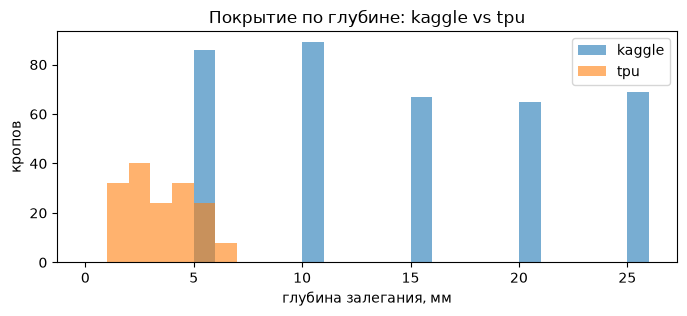

In [21]:
# Распределение таргета по доменам
fig, ax = plt.subplots(figsize=(8,3))
ax.hist([r[3] for r in idx_kaggle], bins=np.arange(0,27,1), alpha=.6, label="kaggle")
ax.hist([r[3] for r in idx_tpu],    bins=np.arange(0,27,1), alpha=.6, label="tpu")
ax.set_xlabel("глубина залегания, мм"); ax.set_ylabel("кропов"); ax.legend()
ax.set_title("Покрытие по глубине: kaggle vs tpu"); plt.show()

## Эксперимент 1 — перенос kaggle → tpu

Обучаем на всём kaggle, тестируем на всём tpu. Ожидаем заметную ошибку: tpu-глубины
(0.5–6 мм) лежат ниже kaggle-сетки (5–25 мм) — модель экстраполирует.

In [22]:
out1 = M.run(idx_kaggle, idx_tpu, mode=MODE, tag="exp1_kaggle2tpu", device=device)
metrics1 = out1["metrics"].by_domain()
metrics1

Current model: convnext_nano (pretrained=False)
Current model: RegressionModel (device=mps)
START tag=exp1_kaggle2tpu device=mps epochs=20 lr=0.001 params=14963441
epoch   1/20 | train_loss 1.67637 | val_mae 11.3935 мм | val_rmse 12.1410 мм
epoch   2/20 | train_loss 0.47569 | val_mae 11.7434 мм | val_rmse 12.0867 мм
epoch   3/20 | train_loss 0.43261 | val_mae 11.1665 мм | val_rmse 11.6177 мм
epoch   4/20 | train_loss 0.37932 | val_mae 11.6103 мм | val_rmse 12.1194 мм
epoch   5/20 | train_loss 0.32640 | val_mae 13.8132 мм | val_rmse 14.9202 мм
epoch   6/20 | train_loss 0.25816 | val_mae 12.9331 мм | val_rmse 14.9740 мм
epoch   7/20 | train_loss 0.23107 | val_mae 13.3074 мм | val_rmse 14.5798 мм
epoch   8/20 | train_loss 0.18455 | val_mae 14.0966 мм | val_rmse 15.4757 мм
epoch   9/20 | train_loss 0.15873 | val_mae 13.3908 мм | val_rmse 14.6738 мм
epoch  10/20 | train_loss 0.15508 | val_mae 13.6253 мм | val_rmse 15.3735 мм
epoch  11/20 | train_loss 0.12817 | val_mae 13.0276 мм | val_rmse 

{'tpu': {'mae_mm': 14.584666752815247,
  'rmse_mm': 15.811698853076265,
  'medae_mm': 13.626196384429932,
  'bias_mm': 14.584666752815247,
  'r2': -104.6108064160141,
  'acc_quant': 0.0,
  'qwk_quant': 0.0},
 'all': {'mae_mm': 14.584666752815247,
  'rmse_mm': 15.811698853076265,
  'medae_mm': 13.626196384429932,
  'bias_mm': 14.584666752815247,
  'r2': -104.6108064160141,
  'acc_quant': 0.0,
  'qwk_quant': 0.0}}

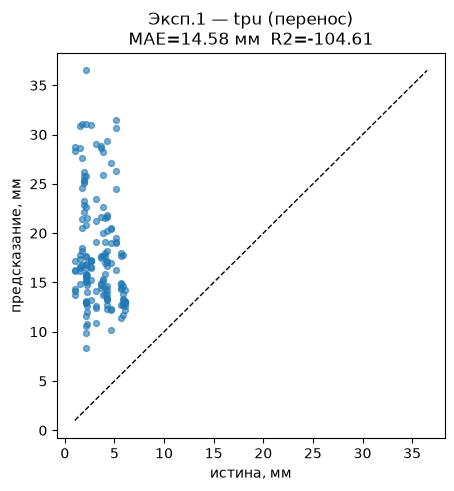

In [23]:
# pred vs true на tpu
def scatter_pred(rm, title):
    yt, yp = rm.y_true, rm.y_pred
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    fig, ax = plt.subplots(figsize=(5,5))
    ax.scatter(yt, yp, s=18, alpha=.6)
    ax.plot([lo,hi],[lo,hi],"k--",lw=1)
    ax.set_xlabel("истина, мм"); ax.set_ylabel("предсказание, мм")
    m = rm.compute(); ax.set_title(f"{title}\nMAE={m['mae_mm']:.2f} мм  R2={m['r2']:.2f}")
    plt.show()

scatter_pred(out1["metrics"], "Эксп.1 — tpu (перенос)")

## Эксперимент 2 — смешанный трейн, раздельный тест

`train = kaggle + часть tpu-видео`, `test = held-out видео каждого домена`. Сплит
строго по видео (у tpu все дефекты одного видео на одной глубине → случайный сплит
= утечка). Метрики считаем раздельно по доменам.

In [24]:
combined = idx_kaggle + idx_tpu
# по 3 held-out видео из каждого домена в тест, остальное — в общий трейн
train_idx, test_idx = M.split_by_video(combined, n_test=3,
                                       domains=["kaggle","tpu"], seed=CFG.train.seed)
def dom_vids(idx, d): return sorted({r[0] for r in idx if r[4]==d})
print("train видео: kaggle=%d tpu=%d" % (len(dom_vids(train_idx,'kaggle')), len(dom_vids(train_idx,'tpu'))))
print("test  видео: kaggle=%d tpu=%d" % (len(dom_vids(test_idx,'kaggle')), len(dom_vids(test_idx,'tpu'))))
print("train кропов=%d test кропов=%d" % (len(train_idx), len(test_idx)))

train видео: kaggle=35 tpu=17
test  видео: kaggle=3 tpu=3
train кропов=492 test кропов=44


In [25]:
out2 = M.run(train_idx, test_idx, mode=MODE, tag="exp2_mixed", device=device)
metrics2 = out2["metrics"].by_domain()
metrics2

Current model: convnext_nano (pretrained=False)
Current model: RegressionModel (device=mps)
START tag=exp2_mixed device=mps epochs=20 lr=0.001 params=14963441
epoch   1/20 | train_loss 1.94553 | val_mae 7.4867 мм | val_rmse 8.9006 мм
epoch   2/20 | train_loss 0.46248 | val_mae 5.8312 мм | val_rmse 6.9583 мм
epoch   3/20 | train_loss 0.45047 | val_mae 5.5463 мм | val_rmse 6.4179 мм
epoch   4/20 | train_loss 0.40177 | val_mae 5.3437 мм | val_rmse 6.0495 мм
epoch   5/20 | train_loss 0.38814 | val_mae 4.9484 мм | val_rmse 5.9673 мм
epoch   6/20 | train_loss 0.38319 | val_mae 4.9797 мм | val_rmse 5.8810 мм
epoch   7/20 | train_loss 0.38008 | val_mae 4.7570 мм | val_rmse 5.7857 мм
epoch   8/20 | train_loss 0.37315 | val_mae 5.2004 мм | val_rmse 6.1899 мм
epoch   9/20 | train_loss 0.35950 | val_mae 4.6847 мм | val_rmse 5.6366 мм
epoch  10/20 | train_loss 0.34862 | val_mae 3.8431 мм | val_rmse 5.2279 мм
epoch  11/20 | train_loss 0.40807 | val_mae 5.8039 мм | val_rmse 6.8087 мм
epoch  12/20 | t

{'kaggle': {'mae_mm': 4.505779814720154,
  'rmse_mm': 5.51859069389712,
  'medae_mm': 4.637018442153931,
  'bias_mm': 3.7554048776626585,
  'r2': 0.31849298189410524,
  'acc_quant': 0.35,
  'qwk_quant': 0.6376811594202898},
 'tpu': {'mae_mm': 2.5491495927174888,
  'rmse_mm': 3.0175011848371853,
  'medae_mm': 1.8828892707824707,
  'bias_mm': 2.481891393661499,
  'r2': -2.7833705393989163,
  'acc_quant': 0.9166666666666666,
  'qwk_quant': 0.0},
 'all': {'mae_mm': 3.4385269663550635,
  'rmse_mm': 4.337008778962779,
  'medae_mm': 2.2288262844085693,
  'bias_mm': 3.0607611591165718,
  'r2': 0.5062257734257567,
  'acc_quant': 0.6590909090909091,
  'qwk_quant': 0.7809734513274337}}

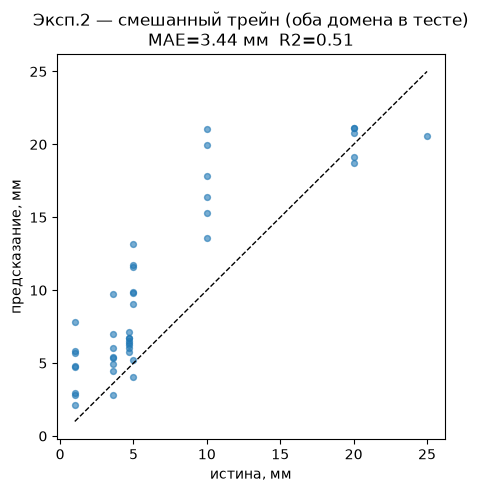

In [26]:
scatter_pred(out2["metrics"], "Эксп.2 — смешанный трейн (оба домена в тесте)")

### (опц.) k-fold по tpu-видео

tpu-видео мало (~20), одиночный held-out из 3 видео = шумная оценка. Ниже —
короткий k-fold: каждый фолд держит часть tpu-видео в тесте, kaggle всегда в трейне
целиком, tpu-train = остальные tpu-видео. Метрику берём по tpu-части теста.

In [ ]:
from collections import defaultdict
tpu_vids = sorted({r[0] for r in idx_tpu})
rng = np.random.default_rng(CFG.train.seed)
tpu_vids = list(rng.permutation(tpu_vids))
K = 4
folds = [tpu_vids[i::K] for i in range(K)]

fold_mae = []
for fi, hold in enumerate(folds, 1):
    hold = set(hold)
    tpu_tr = [r for r in idx_tpu if r[0] not in hold]
    tpu_te = [r for r in idx_tpu if r[0] in hold]
    tr = idx_kaggle + tpu_tr
    res = M.run(tr, tpu_te, mode=MODE, tag=f"exp2_kfold{fi}", device=device)
    m = res["metrics"].compute()
    fold_mae.append(m["mae_mm"])
    print(f"fold {fi}: hold tpu-видео={len(hold)} | tpu MAE={m['mae_mm']:.2f} мм  R2={m['r2']:.2f}")

print(f"\nk-fold tpu MAE: {np.mean(fold_mae):.2f} ± {np.std(fold_mae):.2f} мм")

## Оптимизатор: Adam vs Muon

Muon применяется к 2D+ скрытым весам (свёртки решейпятся к 2D), Adam — к
bias/нормам/голове. Сравним на сетапе Эксп.2 (смешанный трейн). Переключение —
через `CFG.optim.name`.

In [ ]:
cmp = {}
for opt in ["adam", "muon"]:
    CFG.optim.name = opt
    res = M.run(train_idx, test_idx, mode=MODE, tag=f"opt_{opt}", device=device)
    cmp[opt] = res["metrics"].by_domain()
CFG.optim.name = "adam"   # вернуть дефолт

import pandas as pd
rows = [{"optim": o, "domain": d, **{k:round(v,3) for k,v in m.items()}}
        for o, dd in cmp.items() for d, m in dd.items()]
pd.DataFrame(rows).set_index(["optim","domain"])[["mae_mm","rmse_mm","r2"]]

## Экспериментальная сетка (Muon)

`{convnext_nano, resnet34} × {p5, p5+d1} × {30, 50 эпох}` — 8 конфигураций,
оптимизатор только **Muon**. Сетап — смешанный трейн Эксп.2 (`train_idx`/`test_idx`),
метрики раздельно по доменам. Тяжёлый прогон: 8 обучений timm-сетей.

In [34]:
import pandas as pd, itertools
CFG.optim.name = "muon"

grid = list(itertools.product(
    ["resnet34"],
    # ["convnext_nano", "resnet34"],      # модель
    [Modes.p5, Modes.p5_d1, Modes.p5_d1_d2],            # каналы
    [25, 45, 60],                          # эпох
))

grid_rows, grid_metrics = [], {}
for model_name, mode, ep in grid:
    CFG.model.name = model_name
    CFG.train.epochs = ep
    key = f"{model_name}|{mode.value}|{ep}ep"
    print(f"\n########## {key} ##########")
    res = M.run(train_idx, test_idx, mode=mode, tag=f"grid_{key}", device=device)
    grid_metrics[key] = res["metrics"]
    for dom, m in res["metrics"].by_domain().items():
        grid_rows.append({"model": model_name, "mode": mode.value, "epochs": ep,
                          "domain": dom, **{k: round(v, 3) for k, v in m.items()}})

grid_df = pd.DataFrame(grid_rows)


########## resnet34|p5|25ep ##########
Current model: resnet34 (pretrained=False)
Current model: RegressionModel (device=mps)
[muon] params: muon-группа=21277056 adam-группа=17537
START tag=grid_resnet34|p5|25ep device=mps epochs=25 lr=0.001 params=21294593
epoch   1/25 | train_loss 0.36434 | val_mae 6.6345 мм | val_rmse 7.0069 мм
epoch   2/25 | train_loss 0.26962 | val_mae 5.7644 мм | val_rmse 6.1463 мм
epoch   3/25 | train_loss 0.23677 | val_mae 5.3820 мм | val_rmse 5.8609 мм
epoch   4/25 | train_loss 0.17869 | val_mae 5.1008 мм | val_rmse 5.9297 мм
epoch   5/25 | train_loss 0.12964 | val_mae 3.2962 мм | val_rmse 4.6978 мм
epoch   6/25 | train_loss 0.09829 | val_mae 2.5313 мм | val_rmse 3.7662 мм
epoch   7/25 | train_loss 0.08258 | val_mae 1.7692 мм | val_rmse 2.5057 мм
epoch   8/25 | train_loss 0.08001 | val_mae 2.1128 мм | val_rmse 2.7495 мм
epoch   9/25 | train_loss 0.08761 | val_mae 1.8030 мм | val_rmse 2.5982 мм
epoch  10/25 | train_loss 0.05440 | val_mae 1.8715 мм | val_rmse 2

/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)


Current model: RegressionModel (device=mps)
[muon] params: muon-группа=21277056 adam-группа=17537
START tag=grid_resnet34|p5|45ep device=mps epochs=45 lr=0.001 params=21294593
epoch   1/45 | train_loss 0.36434 | val_mae 6.6345 мм | val_rmse 7.0069 мм
epoch   2/45 | train_loss 0.26962 | val_mae 5.7644 мм | val_rmse 6.1463 мм
epoch   3/45 | train_loss 0.23677 | val_mae 5.3820 мм | val_rmse 5.8609 мм
epoch   4/45 | train_loss 0.17869 | val_mae 5.1008 мм | val_rmse 5.9297 мм
epoch   5/45 | train_loss 0.12964 | val_mae 3.2962 мм | val_rmse 4.6978 мм
epoch   6/45 | train_loss 0.09829 | val_mae 2.5313 мм | val_rmse 3.7662 мм
epoch   7/45 | train_loss 0.08258 | val_mae 1.7692 мм | val_rmse 2.5057 мм
epoch   8/45 | train_loss 0.08001 | val_mae 2.1128 мм | val_rmse 2.7495 мм
epoch   9/45 | train_loss 0.08761 | val_mae 1.8030 мм | val_rmse 2.5982 мм
epoch  10/45 | train_loss 0.05440 | val_mae 1.8715 мм | val_rmse 2.4718 мм
epoch  11/45 | train_loss 0.05924 | val_mae 1.3826 мм | val_rmse 2.0305 мм

/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)


Current model: RegressionModel (device=mps)
[muon] params: muon-группа=21277056 adam-группа=17537
START tag=grid_resnet34|p5|60ep device=mps epochs=60 lr=0.001 params=21294593
epoch   1/60 | train_loss 0.36434 | val_mae 6.6345 мм | val_rmse 7.0069 мм
epoch   2/60 | train_loss 0.26962 | val_mae 5.7644 мм | val_rmse 6.1463 мм
epoch   3/60 | train_loss 0.23677 | val_mae 5.3820 мм | val_rmse 5.8609 мм
epoch   4/60 | train_loss 0.17869 | val_mae 5.1008 мм | val_rmse 5.9297 мм
epoch   5/60 | train_loss 0.12964 | val_mae 3.2962 мм | val_rmse 4.6978 мм
epoch   6/60 | train_loss 0.09829 | val_mae 2.5313 мм | val_rmse 3.7662 мм
epoch   7/60 | train_loss 0.08258 | val_mae 1.7692 мм | val_rmse 2.5057 мм
epoch   8/60 | train_loss 0.08001 | val_mae 2.1128 мм | val_rmse 2.7495 мм
epoch   9/60 | train_loss 0.08761 | val_mae 1.8030 мм | val_rmse 2.5982 мм
epoch  10/60 | train_loss 0.05440 | val_mae 1.8715 мм | val_rmse 2.4718 мм
epoch  11/60 | train_loss 0.05924 | val_mae 1.3826 мм | val_rmse 2.0305 мм

...

/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)


Current model: RegressionModel (device=mps)
[muon] params: muon-группа=21305280 adam-группа=17537
START tag=grid_resnet34|p5+d1+d2|45ep device=mps epochs=45 lr=0.001 params=21322817
epoch   1/45 | train_loss 0.36118 | val_mae 5.9914 мм | val_rmse 6.4924 мм
epoch   2/45 | train_loss 0.27160 | val_mae 5.3802 мм | val_rmse 5.9529 мм
epoch   3/45 | train_loss 0.23128 | val_mae 4.7932 мм | val_rmse 5.5284 мм
epoch   4/45 | train_loss 0.20512 | val_mae 4.6545 мм | val_rmse 5.5684 мм
epoch   5/45 | train_loss 0.14944 | val_mae 3.6429 мм | val_rmse 5.3705 мм
epoch   6/45 | train_loss 0.13069 | val_mae 3.1653 мм | val_rmse 4.4924 мм
epoch   7/45 | train_loss 0.11000 | val_mae 2.0110 мм | val_rmse 3.5642 мм
epoch   8/45 | train_loss 0.08486 | val_mae 2.1709 мм | val_rmse 3.0183 мм
epoch   9/45 | train_loss 0.07011 | val_mae 1.5520 мм | val_rmse 2.2720 мм
epoch  10/45 | train_loss 0.05939 | val_mae 1.4904 мм | val_rmse 2.0790 мм
epoch  11/45 | train_loss 0.05807 | val_mae 1.3397 мм | val_rmse 2.0

/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)


Current model: RegressionModel (device=mps)
[muon] params: muon-группа=21305280 adam-группа=17537
START tag=grid_resnet34|p5+d1+d2|60ep device=mps epochs=60 lr=0.001 params=21322817
epoch   1/60 | train_loss 0.36118 | val_mae 5.9914 мм | val_rmse 6.4924 мм
epoch   2/60 | train_loss 0.27160 | val_mae 5.3802 мм | val_rmse 5.9529 мм
epoch   3/60 | train_loss 0.23128 | val_mae 4.7932 мм | val_rmse 5.5284 мм
epoch   4/60 | train_loss 0.20512 | val_mae 4.6545 мм | val_rmse 5.5684 мм
epoch   5/60 | train_loss 0.14944 | val_mae 3.6429 мм | val_rmse 5.3705 мм
epoch   6/60 | train_loss 0.13069 | val_mae 3.1653 мм | val_rmse 4.4924 мм
epoch   7/60 | train_loss 0.11000 | val_mae 2.0110 мм | val_rmse 3.5642 мм
epoch   8/60 | train_loss 0.08486 | val_mae 2.1709 мм | val_rmse 3.0183 мм
epoch   9/60 | train_loss 0.07011 | val_mae 1.5520 мм | val_rmse 2.2720 мм
epoch  10/60 | train_loss 0.05939 | val_mae 1.4904 мм | val_rmse 2.0790 мм
epoch  11/60 | train_loss 0.05807 | val_mae 1.3397 мм | val_rmse 2.0

/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)


In [31]:
# сводка: по конфигу и домену (ключевые метрики)
tbl = (grid_df.set_index(["model","mode","epochs","domain"])
              [["mae_mm","rmse_mm","r2"]])
tbl

mae_mm  rmse_mm     r2
model         mode  epochs domain                        
convnext_nano p5    30     kaggle   1.045    1.259  0.965
                           tpu      1.477    1.650 -0.131
                           all      1.281    1.485  0.942
                    50     kaggle   0.772    0.897  0.982
                           tpu      1.275    1.426  0.155
                           all      1.047    1.215  0.961
              p5+d1 30     kaggle   0.989    1.240  0.966
                           tpu      1.359    1.534  0.022
                           all      1.191    1.408  0.948
                    50     kaggle   0.797    0.913  0.981
                           tpu      1.330    1.535  0.020
                           all      1.088    1.290  0.956
resnet34      p5    30     kaggle   1.218    1.859  0.923
                           tpu      0.927    1.204  0.398
                           all      1.059    1.537  0.938
                    50     kaggle   0.869    1.617  0.941
                           tpu      0.949    1.181  0.420
                           all      0.913    1.397  0.949
              p5+d1 30     kaggle   1.413    2.027  0.908
                           tpu      0.885    1.099  0.498
                           all      1.125    1.590  0.934
                    50     kaggle   1.140    2.112  0.900
                           tpu      0.797    1.001  0.584
                           all      0.953    1.604  0.932

In [32]:
# лучшие по tpu MAE (основная метрика на непокрытом диапазоне)
(grid_df[grid_df.domain=="tpu"]
   .sort_values("mae_mm")[["model","mode","epochs","mae_mm","rmse_mm"]]
   .reset_index(drop=True))

,model,mode,epochs,mae_mm,rmse_mm
0,resnet34,p5+d1,50,0.797,1.001
1,resnet34,p5+d1,30,0.885,1.099
2,resnet34,p5,30,0.927,1.204
3,resnet34,p5,50,0.949,1.181
4,convnext_nano,p5,50,1.275,1.426
5,convnext_nano,p5+d1,50,1.330,1.535
6,convnext_nano,p5+d1,30,1.359,1.534
7,convnext_nano,p5,30,1.477,1.650


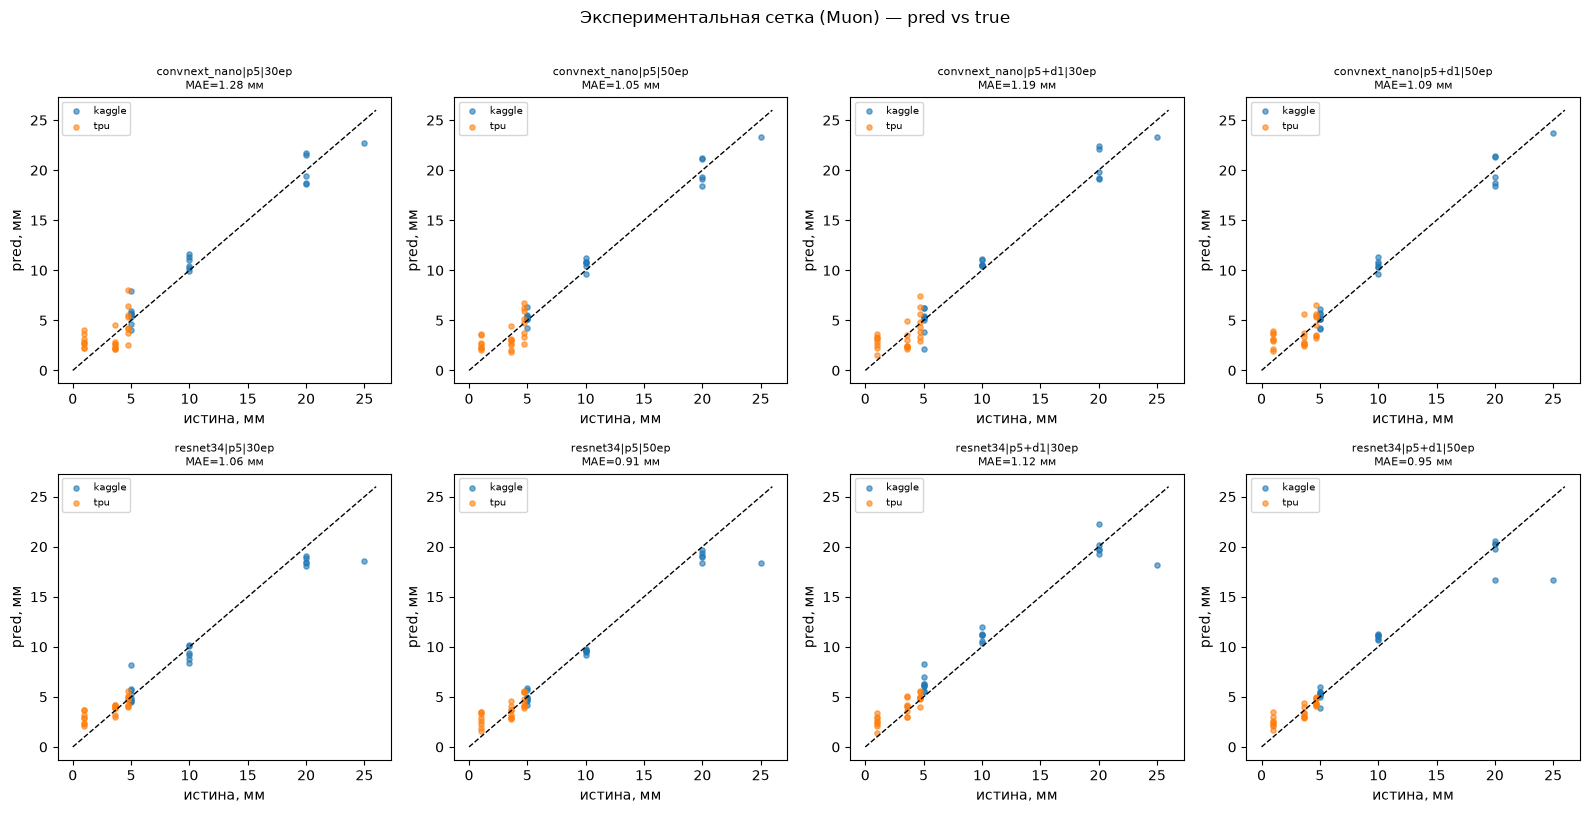

In [33]:
# pred/true по всем 8 конфигурациям
n = len(grid_metrics); ncol = 4; nrow = (n + ncol - 1)//ncol
fig, axs = plt.subplots(nrow, ncol, figsize=(4*ncol, 4*nrow))
axs = np.atleast_1d(axs).ravel()
colors = {"kaggle": "tab:blue", "tpu": "tab:orange"}
for ax, (key, rm) in zip(axs, grid_metrics.items()):
    dom = np.array([r[4] for r in test_idx])
    for d in ["kaggle","tpu"]:
        mmask = dom==d
        ax.scatter(rm.y_true[mmask], rm.y_pred[mmask], s=14, alpha=.6,
                   color=colors[d], label=d)
    lo, hi = 0, max(rm.y_true.max(), rm.y_pred.max())+1
    ax.plot([lo,hi],[lo,hi],"k--",lw=1)
    mm = rm.compute()
    ax.set_title(f"{key}\nMAE={mm['mae_mm']:.2f} мм", fontsize=8)
    ax.set_xlabel("истина, мм"); ax.set_ylabel("pred, мм")
    ax.legend(fontsize=7)
for ax in axs[n:]:
    ax.axis("off")
fig.suptitle("Экспериментальная сетка (Muon) — pred vs true", y=1.01)
plt.tight_layout(); plt.show()

## Выводы

- **Эксп.1 (перенос):** MAE на tpu отражает экстраполяцию вниз по шкале — базовая
  оценка «в лоб», без tpu в трейне.
- **Эксп.2 (смесь):** добавление tpu-видео в трейн закрывает диапазон 0.5–25 мм;
  сравни tpu-MAE с Эксп.1 — падение = выигрыш от покрытия. kaggle-MAE показывает,
  что смешение не ломает «глубокую» зону.
- **Раздельные метрики** не дают домену с бо́льшим числом кропов задавить второй.
- k-fold по tpu даёт устойчивую оценку (±) вместо одиночного шумного теста.

Дальше: вариант C (μ,σ) для доверия на инференсе; подмена GT-маски на маску от
модели сегментации при разборе сырого видео.

## Оценённые глубины на тесте

Предсказания модели Эксп.2 (`out2`) по каждому тестовому кропу и агрегировано по
видео (у tpu все дефекты видео на одной глубине → сравниваем среднее предсказание
с истиной).

In [27]:
import pandas as pd
rm = out2["metrics"]                       # y_true/y_pred в порядке test_idx (shuffle=False)
df = pd.DataFrame({
    "vid":      [r[0] for r in test_idx],
    "domain":   [r[4] for r in test_idx],
    "true_mm":  np.round(rm.y_true, 2),
    "pred_mm":  np.round(rm.y_pred, 2),
})
df["err_mm"] = np.round(df.pred_mm - df.true_mm, 2)
print("=== по кропам ===")
df

=== по кропам ===


,vid,domain,true_mm,pred_mm,err_mm
0,R_020,kaggle,5.0,4.03,-0.97
1,R_020,kaggle,10.0,16.42,6.42
2,R_020,kaggle,10.0,13.55,3.55
3,R_020,kaggle,20.0,18.75,-1.25
4,R_020,kaggle,20.0,21.12,1.12
5,R_020,kaggle,20.0,19.15,-0.85
6,Z_004,kaggle,5.0,13.14,8.14
7,Z_004,kaggle,5.0,11.75,6.75
8,Z_004,kaggle,5.0,9.07,4.07
9,Z_004,kaggle,5.0,9.88,4.88


In [28]:
# агрегировано по видео: истина, среднее предсказание, разброс, ошибка
g = (df.groupby(["domain","vid"])
       .agg(true_mm=("true_mm","first"),
            pred_mm_mean=("pred_mm","mean"),
            pred_mm_std=("pred_mm","std"),
            n=("pred_mm","size"))
       .reset_index())
g["pred_mm_mean"] = g.pred_mm_mean.round(2)
g["pred_mm_std"]  = g.pred_mm_std.round(2)
g["err_mm"]       = (g.pred_mm_mean - g.true_mm).round(2)
print("=== по видео (агрегировано) ===")
g.sort_values(["domain","true_mm"])

=== по видео (агрегировано) ===


,domain,vid,true_mm,pred_mm_mean,pred_mm_std,n,err_mm
0,kaggle,R_020,5.0,15.50,6.19,6,10.50
1,kaggle,Z_004,5.0,15.55,5.05,12,10.55
2,kaggle,Z_011,5.0,10.24,7.13,2,5.24
3,tpu,Sample_3_Static,1.0,4.58,1.90,8,3.58
4,tpu,Sample_4_Static,3.6,5.72,2.04,8,2.12
5,tpu,Sample_8_Static,4.7,6.44,0.43,8,1.74


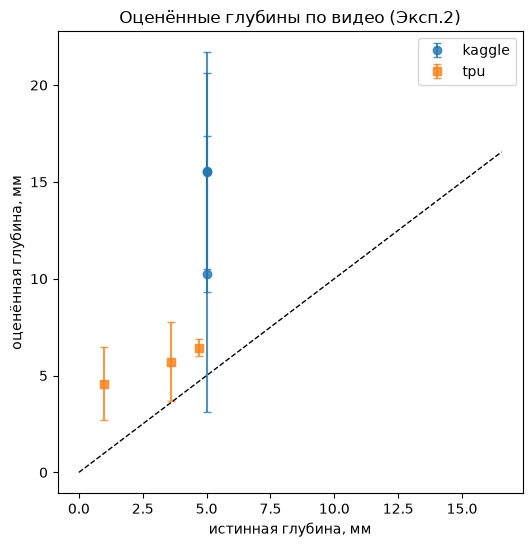

In [29]:
# истина vs предсказание по видео
fig, ax = plt.subplots(figsize=(6,6))
for d, mk in [("kaggle","o"), ("tpu","s")]:
    s = g[g.domain==d]
    ax.errorbar(s.true_mm, s.pred_mm_mean, yerr=s.pred_mm_std, fmt=mk,
                capsize=3, label=d, alpha=.8)
lo, hi = 0, max(g.true_mm.max(), g.pred_mm_mean.max())+1
ax.plot([lo,hi],[lo,hi],"k--",lw=1)
ax.set_xlabel("истинная глубина, мм"); ax.set_ylabel("оценённая глубина, мм")
ax.set_title("Оценённые глубины по видео (Эксп.2)"); ax.legend(); plt.show()